In [27]:
# Importing Required Libraries
'''
pandas, numpy, matplotlib for data and plotting
tabulate for tables
'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from matplotlib.ticker import PercentFormatter

In [28]:
# Data Loading
'''
loading of the csv file to the notebook
'''
try :
  df = pd.read_csv("sp500_10s.csv")
  print(df.head())
except FileNotFoundError:
    print("Error: The file was not found. Please check the file path.")
except pd.errors.EmptyDataError:
    print("Error: The file is empty.")
except pd.errors.ParserError:
    print("Error: There was a problem parsing the file. Please check the file format.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

         date     open     high      low    close     volume  Name
0  2013-02-08  67.7142  68.4014  66.8928  67.8542  158168416  AAPL
1  2013-02-11  68.0714  69.2771  67.6071  68.5614  129029425  AAPL
2  2013-02-12  68.5014  68.9114  66.8205  66.8428  151829363  AAPL
3  2013-02-13  66.7442  67.6628  66.1742  66.7156  118721995  AAPL
4  2013-02-14  66.3599  67.3771  66.2885  66.6556   88809154  AAPL


In [29]:
# Data Cleaning
'''
cleaning data within the csv file
'''
try :
  df['date'] = pd.to_datetime(df['date'])
  df = df.sort_values(by='date')

  df_grouped = df.groupby(['date', 'Name']).mean(numeric_only=True).reset_index()

  close_prices = df_grouped.pivot(index='date', columns='Name', values='close')
  close_prices.dropna(inplace=True)
  print("Data cleaning completed successfully!")
except KeyError as e:
    print(f"Error: Column '{e}' not found in the DataFrame. Please check your data.")
except TypeError as e:
    print(f"Error: {e}. Check data types and ensure compatibility with operations.")
except ValueError as e:
    print(f"Error: {e}. This could be due to invalid data or formatting issues.")
except Exception as e:
    print(f"An unexpected error occurred during data cleaning: {e}")

Data cleaning completed successfully!


In [30]:
# Calculating Returns
'''
calculation of returns from csv file
'''
returns = close_prices.pct_change().dropna()
if len(returns) < 10:
    raise ValueError("Insufficient data after calculating returns. Need more price history.")

In [31]:
# Constraint-Based Fitness Function
'''
Evaluation of portfolio based on Sharpe Ratio while taking constraints into account
For GA, constraints are placed within the Fitness Function to take proper effect
'''

last_prices = close_prices.iloc[-1].values  # use latest close prices
max_allowed_drawdown = -0.25  # max drawdown of -25%
rf = 0.04 / 252  # risk-free rate (4% - annualized, daily)

# Max Drawdown Calculation
'''
computes maximum observed loss from a peak to a trough
returns negative value
'''
def max_drawdown(cumulative_returns):
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()

# Constrained Fitness
def fitness_constrained(weights):
    # Computation of cumulative returns
    port_returns = returns @ weights
    cumulative = (1 + port_returns).cumprod()

    # Max Drawdown constraint
    mdd = max_drawdown(cumulative)  # evaluating max drawdown of portfolio
    if mdd < max_allowed_drawdown:
        return 0                    # discard portfolio if violation of drawdown constraint

    # Sharpe Ratio
    '''
    (return - risk) / volatility
    '''
    port_return = np.mean(port_returns)
    port_volatility = np.std(port_returns)
    if port_volatility == 0:
        return 0

    return port_return / port_volatility


In [32]:
# Genetic Algorithm

# Calculate the mean returns and covariance matrix of the assets
mean_returns = returns.mean()
cov_matrix = returns.cov()

# Define parameters for the genetic algorithm
population_size = 200
generations = 250
mutation_rate = 0.1

# Get the number of assets in the portfolio
n_assets = len(mean_returns)

# Function to generate a random portfolio with weights summing to 1
def portfolio_generation():
    weights = np.random.rand(n_assets)
    return weights / np.sum(weights)

# Fitness function to evaluate the performance of a portfolio (Sharpe Ratio)
def fitness(weights):
    potential_return = np.dot(weights, mean_returns)
    potential_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    return potential_return/potential_volatility if potential_volatility else 0

# Initialize the population with random portfolios
population = np.array([portfolio_generation() for _ in range(population_size)])
history = []  # Store the best fitness score for each generation

In [33]:
# Generation Evolution

# Iterate through the specified number of generations
for generation in range(generations):
    # Calculate the fitness score for each individual in the population
    scores = np.array([fitness(ind) for ind in population])

    # Select the top-performing individuals as parents for the next generation
    top_indices = np.argsort(scores)[-population_size//2:]  # Get indices of top half
    top_performers = population[top_indices]

    # Check if any portfolios passed the constraints
    if len(top_performers) == 0:
        raise RuntimeError("No valid portfolios passed constraints. Try adjusting drawdown or mutation rate")

    # Create offspring (children) from the selected parents
    children = []

    # Generate children until the population size is reached
    while len(children) < population_size:
        # Randomly select two parents from the top performers
        parent1, parent2 = top_performers[np.random.randint(len(top_performers), size=2)]

        # Determine a crossover point for combining parent genes
        if n_assets > 2:
            point = np.random.randint(1, n_assets-1)
        else:
            point = 1

        # Create a child by combining genes from the parents
        child = np.concatenate((parent1[:point], parent2[point:]))
        child = child/np.sum(child) # Normalize weights to sum to 1

        # Introduce random mutations to the child's gene
        if np.random.rand() < mutation_rate:
            mutation = np.random.rand(n_assets)
            child = (child + mutation) / np.sum(child + mutation)   # Normalise

        # Add the child to the new generation
        children.append(child)

    # Replace the current population with the new generation
    population = np.array(children)
    history.append(scores.max())  # Record the best fitness score of the generation

In [34]:
# Best Portfolio

# Evaluate the fitness of the final population
final_scores = np.array([fitness(ind) for ind in population])

# Identify the individual with the highest fitness score
best_index = np.argmax(final_scores)
best_weights = population[best_index]

# Calculate the return, volatility, and Sharpe Ratio of the best portfolio
best_return = np.dot(best_weights, mean_returns)
best_volatility = np.sqrt(np.dot(best_weights.T, np.dot(cov_matrix, best_weights)))
best_sharpe = final_scores[best_index]

# Get the tickers of the assets
tickers = mean_returns.index.tolist()

# Create a DataFrame to store the portfolio allocation
best_portfolio = pd.DataFrame({'Ticker':tickers, 'Weight':best_weights}).sort_values(by='Weight', ascending=False)

In [35]:
# Fitness Function for Min Volatility

def fitness_min_volatility(weights):
    # Calculate portfolio returns
    port_returns = returns @ weights

    # Calculate cumulative returns
    cumulative = (1 + port_returns).cumprod()

    # Calculate Max Drawdown
    mdd = max_drawdown(cumulative)

    # Check for drawdown constraint violation
    if mdd < max_allowed_drawdown:
        return np.inf   # Return infinity if constraint violated, penalise portfolio

    # Calculate portfolio volatility
    port_volatility = np.std(port_returns)

    # Return portfolio volatility as fitness value
    return port_volatility


In [36]:

# Genetic Algorithm Running Function
'''
function for running GA with given Fitness Function
same as previous section, with addition of Fitness Function specification
'''

def run_ga(fitness_func):
    population = np.array([portfolio_generation() for _ in range(population_size)])   # Initialize population
    history = []  # Store the best fitness score for each generation

    for _ in range(generations):
        scores = np.array([fitness_func(ind) for ind in population])  # Calculate fitness scores
        top_indices = scores.argsort()[:population_size // 2]         # Select top performers
        top_performers = population[top_indices]                      # Get top performers

        if len(top_performers) == 0:
          raise RuntimeError("No valid portfolios passed constraints. Try adjusting drawdown or mutation rate")

        children = []   # offspring creation

        # Generate children until population size is reached
        while len(children) < population_size:
            # Parent Selection
            p1, p2 = top_performers[np.random.randint(len(top_performers), size=2)]

            # Crossover Point
            point = np.random.randint(1, n_assets - 1) if n_assets > 2 else 1

            # Child Creation
            child = np.concatenate((p1[:point], p2[point:]))

            # Weight Normalisation
            child = child / np.sum(child)

            # Mutation
            if np.random.rand() < mutation_rate:
                mutation = np.random.rand(n_assets)
                child = (child + mutation) / np.sum(child + mutation)   # Normalise

            children.append(child)  # Add child to the new generation

        population = np.array(children)   # Replace population with new generation
        history.append(scores.min())      # Record best fitness score

    # Calculate final fitness scores
    final_scores = np.array([fitness_func(ind) for ind in population])

    # Identify best individual
    best_index = np.argmin(final_scores)

    # Get best weights
    best_weights = population[best_index]

    # Return best weights
    return best_weights


In [37]:

# Run GA for both Max Sharpe and Min Volatility
best_weights_sharpe = run_ga(fitness_constrained)     # Run GA for Max Sharpe
best_weights_minvol = run_ga(fitness_min_volatility)  # Run GA for Min Vol

def portfolio_stats(weights, rf_annual = 0.04, trading_days = 252):
    port_returns = returns @ weights
    mean_dailty_return = np.mean(port_returns)
    daily_vol = np.std(port_returns)

    # Annualised Metrics
    ret = mean_dailty_return * trading_days
    vol = daily_vol * np.sqrt(trading_days)
    sharpe = (ret - rf_annual) / vol if vol > 0 else 0
    return ret, vol, sharpe

ret_s, vol_s, sharpe_s = portfolio_stats(best_weights_sharpe)   # Calculate stats for Max Sharpe portfolio
ret_v, vol_v, sharpe_v = portfolio_stats(best_weights_minvol)   # Calculate stats for Min Vol portfolio

# Compute a blended optimal portfolio (50% Max Sharpe + 50% Min Volatility)
optimal_weights = 0.5 * best_weights_sharpe + 0.5 * best_weights_minvol
ret_o, vol_o, sharpe_o = portfolio_stats(optimal_weights)     # Calculate stats for Blended Optimal portfolio




=== Optimal Portfolio Allocation Comparison ===
| Asset   |   Max Sharpe (%) |   Min Volatility (%) |
|---------|------------------|----------------------|
| AAPL    |             5.45 |                11.02 |
| AMZN    |             9.44 |                 0.23 |
| BAC     |            11.25 |                 5.75 |
| CHK     |            11.2  |                 0.44 |
| GOOGL   |            15.82 |                 7.5  |
| JNJ     |             9.11 |                41.07 |
| MSFT    |            16.78 |                 2.03 |
| NFLX    |             7.52 |                 0.6  |
| V       |            12.71 |                 3.13 |
| WMT     |             0.72 |                28.24 |

=== Performance Metrics ===
+----------------+--------+------------+--------------+
|   Portfolio    | Return | Volatility | Sharpe Ratio |
+----------------+--------+------------+--------------+
|   Max Sharpe   | 21.65% |   17.35%   |     1.02     |
| Min Volatility | 14.25% |   11.95%   |     0.86 

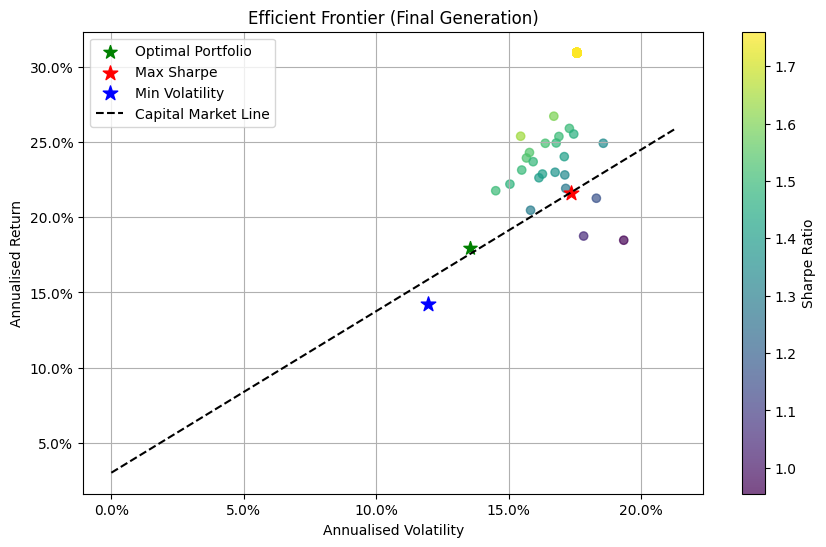

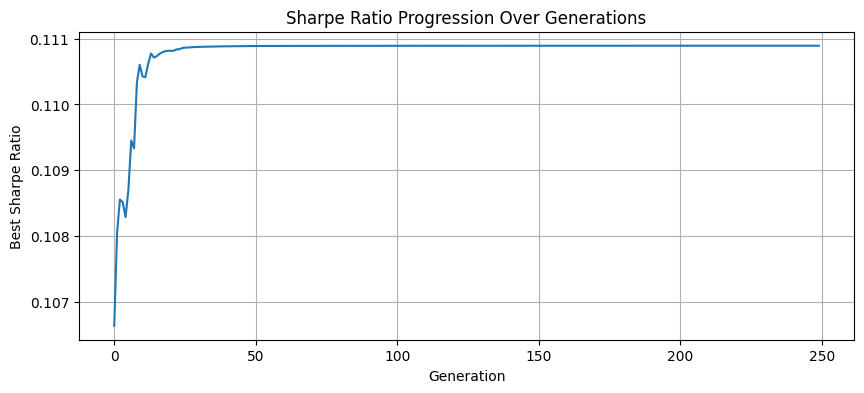

In [38]:
# Output Section
'''
display of results
'''

# Allocation Table
print("\n=== Optimal Portfolio Allocation Comparison ===")
alloc_df = pd.DataFrame({
    'Asset': tickers,
    'Max Sharpe (%)': [f"{w * 100:.2f}" for w in best_weights_sharpe],
    'Min Volatility (%)': [f"{w * 100:.2f}" for w in best_weights_minvol]
})

print(tabulate(alloc_df, headers="keys", tablefmt="github", showindex=False))

# Performance Metrics
print("\n=== Performance Metrics ===")
metrics = [
    ["Max Sharpe", f"{ret_s:.2%}", f"{vol_s:.2%}", f"{sharpe_s:.2f}"],
    ["Min Volatility", f"{ret_v:.2%}", f"{vol_v:.2%}", f"{sharpe_v:.2f}"]
]
print(tabulate(metrics, headers=["Portfolio", "Return", "Volatility", "Sharpe Ratio"], tablefmt="pretty"))

# Optimal Portfolio Blend
print("\n=== Blended Optimal Portfolio ===")
print(f"Return: {ret_o:.2%}, Volatility: {vol_o:.2%}, Sharpe Ratio: {sharpe_o:.2f}")

# Plot Results
'''
plots Efficient Frontier
highlights Optimal Portfolio, Max Sharpe, Min Volatility
includes Capital Market Line
'''
trading_days = 252
final_returns = np.dot(population, mean_returns)*trading_days
final_volatilities = np.sqrt(np.sum(population @ cov_matrix * population, axis=1))*np.sqrt(trading_days)
final_sharpes = final_returns / final_volatilities

if len(final_returns) == 0 and len(final_volatilities) == 0:
    raise ValueError("Cannot plot Efficient Frontier - portfolio results are empty!")

plt.figure(figsize=(10, 6))
plt.scatter(final_volatilities, final_returns, c=final_sharpes, cmap='viridis', alpha=0.7)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(vol_o, ret_o, color='green', s=100, marker='*', label='Optimal Portfolio')
plt.scatter(vol_s, ret_s, marker='*', color='red', s=120, label='Max Sharpe')
plt.scatter(vol_v, ret_v, marker='*', color='blue', s=120, label='Min Volatility')

# Capital Market Line
rf = 0.03
cml_x = np.linspace(0, max(final_volatilities)*1.1)
cml_y = rf + (ret_s - rf) / vol_s * cml_x
plt.plot(cml_x, cml_y, 'k--', linewidth=1.5, label='Capital Market Line')

plt.xlabel('Annualised Volatility')
plt.ylabel('Annualised Return')
plt.title('Efficient Frontier (Final Generation)')
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid(True)
plt.legend()
plt.show()

# Sharpe Ratio Progression
'''
for GA, generations graph is plotted to show progression of Sharpe Ratio
'''
plt.figure(figsize=(10, 4))
plt.plot(history)
plt.xlabel('Generation')
plt.ylabel('Best Sharpe Ratio')
plt.title('Sharpe Ratio Progression Over Generations')
plt.grid(True)
plt.show()
